# Baseline-Modell — Crop- und Stage-Klassifikation
Einfachste Baseline laut Aufgabenstellung: zwei unabhaengige Modelle (eines fuer Crop, eines fuer Stage) auf denselben Features, 70/30 Split. Vergleich mit hierarchischem/gemeinsamem Ansatz folgt in Meilenstein 2.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, f1_score, ConfusionMatrixDisplay

RANDOM_STATE = 42
df = pd.read_csv('train.csv')

RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xf. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.

## Preprocessing
Komplett leere Spektralband-Spalten werden verworfen (bekannte Absorptionsbaender, siehe `eda.ipynb`). Fuer die restlichen, vereinzelt fehlenden Werte reicht Median-Imputation. Als Features werden die nutzbaren Spektralbaender plus `AEZ` und `Month` verwendet.

In [2]:
spec_cols = [c for c in df.columns if c.startswith('X')]
na_frac = df[spec_cols].isna().mean()
usable_spec_cols = [c for c in spec_cols if na_frac[c] < 1.0]
feature_cols = usable_spec_cols + ['AEZ', 'Month']
print(f'Verwendete Features: {len(feature_cols)} (davon {len(usable_spec_cols)} Spektralbaender)')

X = df[feature_cols]
y_crop = df['Crop']
y_stage = df['Stage']

Verwendete Features: 133 (davon 131 Spektralbaender)


## Stratifizierter 70/30 Split
Stratifizierung auf `Crop`, um die Klassenverteilung in Train/Test zu erhalten.

In [3]:
X_train, X_test, y_crop_train, y_crop_test, y_stage_train, y_stage_test = train_test_split(
    X, y_crop, y_stage, test_size=0.3, stratify=y_crop, random_state=RANDOM_STATE
)
print('Train:', X_train.shape, ' Test:', X_test.shape)

Train: (3913, 133)  Test: (1678, 133)


## Baseline-Modell: Crop-Klassifikation
`RandomForestClassifier` mit `class_weight="balanced"` wegen des Klassenungleichgewichts, eingebettet in eine Pipeline mit Median-Imputation und Skalierung.

Crop - Balanced Accuracy: 0.778
Crop - Macro F1: 0.810


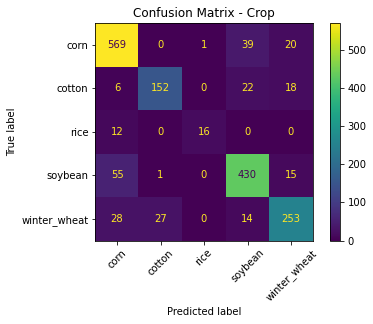

In [4]:
def make_pipeline():
    return Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
        ('clf', RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE)),
    ])

crop_pipeline = make_pipeline()
crop_pipeline.fit(X_train, y_crop_train)
crop_pred = crop_pipeline.predict(X_test)

crop_bacc = balanced_accuracy_score(y_crop_test, crop_pred)
crop_f1 = f1_score(y_crop_test, crop_pred, average='macro')
print(f'Crop - Balanced Accuracy: {crop_bacc:.3f}')
print(f'Crop - Macro F1: {crop_f1:.3f}')

ConfusionMatrixDisplay.from_predictions(y_crop_test, crop_pred, xticks_rotation=45)
plt.title('Confusion Matrix - Crop')
plt.show()

## Baseline-Modell: Stage-Klassifikation

Stage - Balanced Accuracy: 0.769
Stage - Macro F1: 0.788


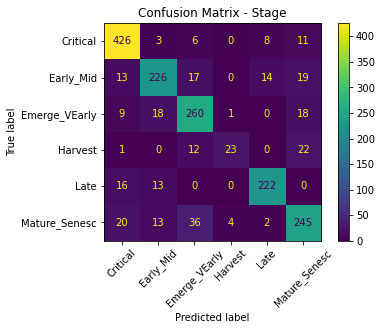

In [5]:
stage_pipeline = make_pipeline()
stage_pipeline.fit(X_train, y_stage_train)
stage_pred = stage_pipeline.predict(X_test)

stage_bacc = balanced_accuracy_score(y_stage_test, stage_pred)
stage_f1 = f1_score(y_stage_test, stage_pred, average='macro')
print(f'Stage - Balanced Accuracy: {stage_bacc:.3f}')
print(f'Stage - Macro F1: {stage_f1:.3f}')

ConfusionMatrixDisplay.from_predictions(y_stage_test, stage_pred, xticks_rotation=45)
plt.title('Confusion Matrix - Stage')
plt.show()

## Zusammenfassung
| Zielgroesse | Balanced Accuracy | Macro F1 |
|---|---|---|
| Crop  | siehe Output oben | siehe Output oben |
| Stage | siehe Output oben | siehe Output oben |

Naechste Schritte (Meilenstein 2): hierarchischen bzw. gemeinsamen Klassifikationsansatz gegen diese Baseline vergleichen, Hyperparameter-Tuning, ggf. Feature-Selektion/PCA.